In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
warnings.filterwarnings('ignore')

In [65]:
df=pd.read_csv(r"C:\Users\aadis\OneDrive\ドキュメント\DATA SCIENCE\PYTHON\ML PROJECTS\Customer churn project\files\Customer Churn.csv")

In [66]:
df=df.drop(['customerID'],axis=1)

# customerID has no role to play in analysis

In [67]:
# Feature engineering

conditions = [
    (df['Dependents'] == 'No') & (df['Partner'] == 'No'),   
    (df['Dependents'] == 'No') & (df['Partner'] == 'Yes'),   
    (df['Dependents'] == 'yes')                           
]

choices = ['Single', 'Couple', 'Family']
df['Family_Status'] = np.select(conditions, choices, default='Unknown')


conditions = [
    (df['tenure'] >= 0) & (df['tenure'] <= 12),   
    (df['tenure'] >= 13) & (df['tenure'] <= 24),  
    (df['tenure'] >= 25) & (df['tenure'] <= 48),  
    (df['tenure'] >= 49)                          
]

choices = ['New customers', 'Developing customers', 'Established customers', 'Loyal customers']
df['Customer_Status'] = np.select(conditions, choices, default='Unknown')

In [68]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [69]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.metrics import precision_score,recall_score, f1_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.model_selection import  GridSearchCV,RandomizedSearchCV
from sklearn.metrics import precision_recall_curve

In [70]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


cols_replace_multi = ['OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies']
for col in cols_replace_multi:
    X_train[col] = X_train[col].replace('No internet service', 'No')
    X_test[col]  = X_test[col].replace('No internet service', 'No')


X_train['MultipleLines'] = X_train['MultipleLines'].replace('No phone service', 'No')
X_test['MultipleLines']  = X_test['MultipleLines'].replace('No phone service', 'No')


yes_no_cols = [col for col in X_train.columns 
               if set(X_train[col].unique()) <= {'Yes','No'}]
for col in yes_no_cols:
    X_train[col] = X_train[col].map({'Yes':1, 'No':0})
    X_test[col]  = X_test[col].map({'Yes':1, 'No':0})


onehot_cols = ['gender','PaymentMethod','Family_Status','Customer_Status','InternetService','Contract']
encoder = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')
encoded_train = encoder.fit_transform(X_train[onehot_cols])
encoded_test  = encoder.transform(X_test[onehot_cols])


encoded_train_df = pd.DataFrame(encoded_train, 
                                columns=encoder.get_feature_names_out(onehot_cols),
                                index=X_train.index)
encoded_test_df  = pd.DataFrame(encoded_test, 
                                columns=encoder.get_feature_names_out(onehot_cols),
                                index=X_test.index)


X_train = pd.concat([X_train.drop(columns=onehot_cols), encoded_train_df], axis=1)
X_test  = pd.concat([X_test.drop(columns=onehot_cols),  encoded_test_df], axis=1)


X_train['TotalCharges'] = pd.to_numeric(X_train['TotalCharges'], errors='coerce')
mask_train = X_train['TotalCharges'].isna()
X_train.loc[mask_train, 'TotalCharges'] = (
    X_train.loc[mask_train, 'tenure'] * X_train.loc[mask_train, 'MonthlyCharges']
)


X_test['TotalCharges'] = pd.to_numeric(X_test['TotalCharges'], errors='coerce')
mask_test = X_test['TotalCharges'].isna()
X_test.loc[mask_test, 'TotalCharges'] = (
    X_test.loc[mask_test, 'tenure'] * X_test.loc[mask_test, 'MonthlyCharges']
)


scale_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
scaler = StandardScaler()
X_train[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_test[scale_cols] = scaler.transform(X_test[scale_cols])


y_train = y_train.map({'Yes':1, 'No':0})
y_test  = y_test.map({'Yes':1, 'No':0})

Train Precision: 0.5212489158716392
Test Precision: 0.4991596638655462
Train Recall: 0.8040133779264214
Test Recall: 0.7941176470588235
Train F1: 0.6324651407524335
Test F1: 0.6130030959752322
[[737 298]
 [ 77 297]]


Text(20.72222222222222, 0.5, 'Actual')

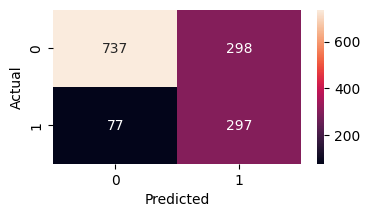

In [101]:
# 1.) Logistic Regression

clf = LogisticRegression(penalty='l2', C=0.5, solver='lbfgs', max_iter=1000, class_weight='balanced',random_state=42)
clf.fit(X_train,y_train)
y_pred = clf.predict(X_test)
y_train_pred = clf.predict(X_train)

print("Train Precision:", precision_score(y_train, y_train_pred))
print("Test Precision:", precision_score(y_test, y_pred))
print("Train Recall:", recall_score(y_train, y_train_pred))
print("Test Recall:", recall_score(y_test, y_pred))
print("Train F1:", f1_score(y_train, y_train_pred))
print("Test F1:", f1_score(y_test, y_pred))
print(confusion_matrix(y_test,y_pred))

plt.figure(figsize=(4,2))
sns.heatmap(confusion_matrix(y_test,y_pred),annot=True,fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")

In [102]:
y_proba = clf.predict_proba(X_test)[:,1]
y_proba

array([0.11024694, 0.88433967, 0.14523103, ..., 0.35313445, 0.02049074,
       0.02249309])

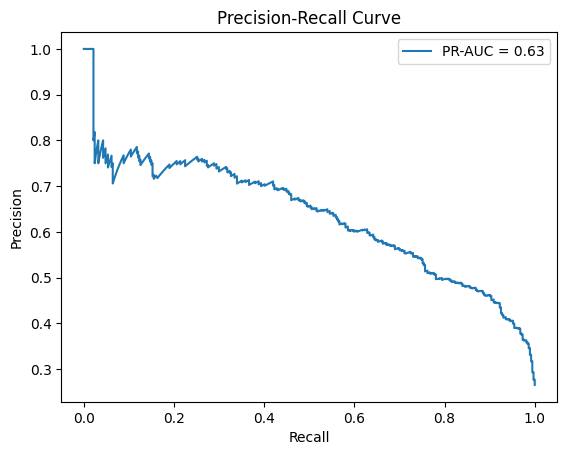

In [103]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, thresholds = precision_recall_curve(y_test, y_proba)
pr_auc = average_precision_score(y_test, y_proba)

plt.plot(recall, precision, label=f"PR-AUC = {pr_auc:.2f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()

In [104]:
f1_scores = 2 * precision * recall / (precision + recall + 1e-10)

# best threshold index
best_idx = np.argmax(f1_scores)

# optimal threshold
best_threshold = thresholds[best_idx]

print("Best Threshold:", best_threshold)
print("Precision:", precision[best_idx])
print("Recall:", recall[best_idx])
print("F1 Score:", f1_scores[best_idx])

Best Threshold: 0.5876607614311167
Precision: 0.5537525354969574
Recall: 0.7299465240641712
F1 Score: 0.62975778541807


Test Precision: 0.5537525354969574
Test Recall: 0.7299465240641712
Test F1: 0.629757785467128
[[737 298]
 [ 77 297]]


Text(20.72222222222222, 0.5, 'Actual')

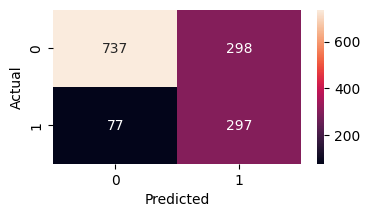

In [105]:
y1_pred = (y_proba >= 0.5876607614311167).astype(int)

print("Test Precision:", precision_score(y_test, y1_pred))
print("Test Recall:", recall_score(y_test, y1_pred))
print("Test F1:", f1_score(y_test, y1_pred))
print(confusion_matrix(y_test,y_pred))

plt.figure(figsize=(4,2))
sns.heatmap(confusion_matrix(y_test,y_pred),annot=True,fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")

Train Precision: 0.7165575304022451
Test Precision: 0.6578947368421053
Train Recall: 0.5123745819397993
Test Recall: 0.4679144385026738
Train F1: 0.5975039001560063
Test F1: 0.546875


Text(20.72222222222222, 0.5, 'Actual')

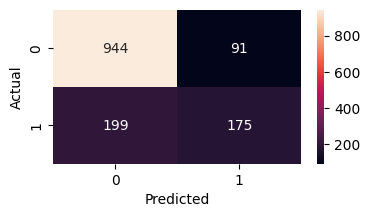

In [76]:
# 2.) SVM

model=SVC(probability=True)         
model.fit(X_train,y_train)
y_pred=model.predict(X_test)
y_train_pred = model.predict(X_train)

print("Train Precision:", precision_score(y_train, y_train_pred))
print("Test Precision:", precision_score(y_test, y_pred))
print("Train Recall:", recall_score(y_train, y_train_pred))
print("Test Recall:", recall_score(y_test, y_pred))
print("Train F1:", f1_score(y_train, y_train_pred))
print("Test F1:", f1_score(y_test, y_pred))

plt.figure(figsize=(4,2))
sns.heatmap(confusion_matrix(y_test,y_pred),annot=True,fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")

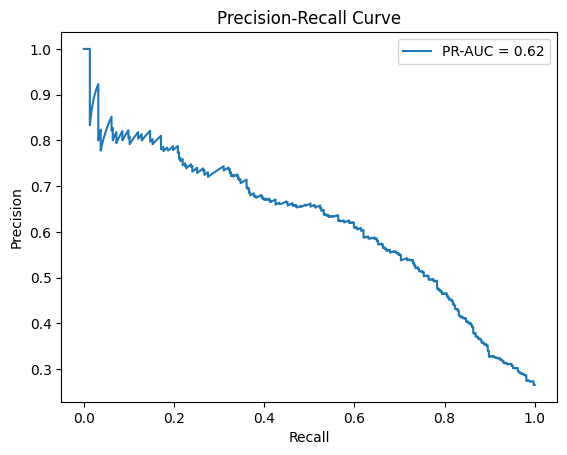

In [77]:
y_proba = model.predict_proba(X_test)[:,1]

from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, thresholds = precision_recall_curve(y_test, y_proba)
pr_auc = average_precision_score(y_test, y_proba)

plt.plot(recall, precision, label=f"PR-AUC = {pr_auc:.2f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()

Train Precision: 0.5313376987839102
Test Precision: 0.5155393053016454
Train Recall: 0.7598662207357859
Test Recall: 0.7540106951871658
Train F1: 0.6253784750894578
Test F1: 0.6123778501628665
[[770 265]
 [ 92 282]]


Text(20.72222222222222, 0.5, 'Actual')

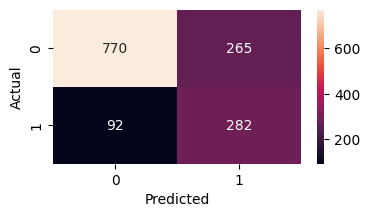

In [78]:
# 3.) Naive Bayes

model_gaussian = GaussianNB()        
model_gaussian.fit(X_train,y_train)
y_pred=model_gaussian.predict(X_test)
y_train_pred = model_gaussian.predict(X_train)

print("Train Precision:", precision_score(y_train, y_train_pred))
print("Test Precision:", precision_score(y_test, y_pred))
print("Train Recall:", recall_score(y_train, y_train_pred))
print("Test Recall:", recall_score(y_test, y_pred))
print("Train F1:", f1_score(y_train, y_train_pred))
print("Test F1:", f1_score(y_test, y_pred))
print(confusion_matrix(y_test,y_pred))

plt.figure(figsize=(4,2))
sns.heatmap(confusion_matrix(y_test,y_pred),annot=True,fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")

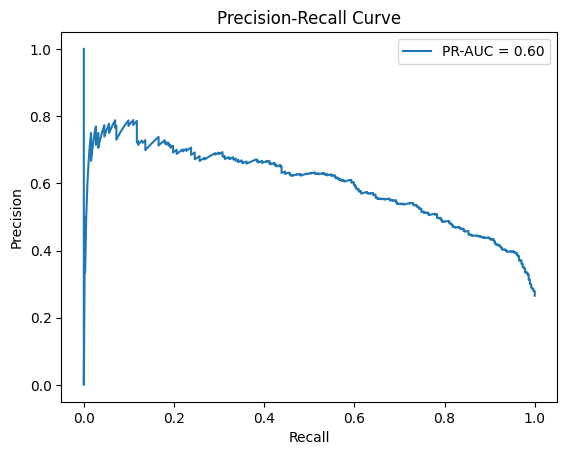

In [79]:
y_proba = model_gaussian.predict_proba(X_test)[:,1]

precision, recall, thresholds = precision_recall_curve(y_test, y_proba)
pr_auc = average_precision_score(y_test, y_proba)

plt.plot(recall, precision, label=f"PR-AUC = {pr_auc:.2f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()

Train Precision: 0.6035714285714285
Test Precision: 0.5045703839122486
Train Recall: 0.9043478260869565
Test Recall: 0.7379679144385026
Train F1: 0.7239625167336011
Test F1: 0.5993485342019544
[[764 271]
 [ 98 276]]


Text(20.72222222222222, 0.5, 'Actual')

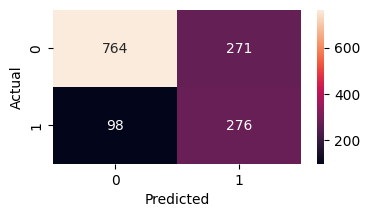

In [80]:
# 5.) Decision Tree

model_DT = DecisionTreeClassifier(criterion="entropy", random_state=42, max_depth=10, class_weight="balanced")      
model_DT.fit(X_train,y_train)
y_pred=model_DT.predict(X_test)
y_train_pred = model_DT.predict(X_train)

print("Train Precision:", precision_score(y_train, y_train_pred))
print("Test Precision:", precision_score(y_test, y_pred))
print("Train Recall:", recall_score(y_train, y_train_pred))
print("Test Recall:", recall_score(y_test, y_pred))
print("Train F1:", f1_score(y_train, y_train_pred))
print("Test F1:", f1_score(y_test, y_pred))
print(confusion_matrix(y_test,y_pred))

plt.figure(figsize=(4,2))
sns.heatmap(confusion_matrix(y_test,y_pred),annot=True,fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")

In [81]:
# Decision Tree with tuning

model_DT = DecisionTreeClassifier(random_state=42,class_weight="balanced") 

dt_param_grid = {
    "max_depth": [3, 5, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "criterion": ["gini", "entropy"],
    "min_impurity_decrease":[0.01,0.001,0.1]
}

# GridSearchCV
dt_grid = GridSearchCV(
    model_DT,
    dt_param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

dt_grid.fit(X_train, y_train)

print("Best params (Decision Tree):", dt_grid.best_params_)
print("Best CV f1:", dt_grid.best_score_)

Best params (Decision Tree): {'criterion': 'entropy', 'max_depth': 5, 'min_impurity_decrease': 0.01, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best CV f1: 0.6204258562219814


Train Precision: 0.5123859191655802
Test Precision: 0.5140350877192983
Train Recall: 0.788628762541806
Test Recall: 0.7834224598930482
Train F1: 0.6211801896733403
Test F1: 0.6207627118644068
[[758 277]
 [ 81 293]]


Text(20.72222222222222, 0.5, 'Actual')

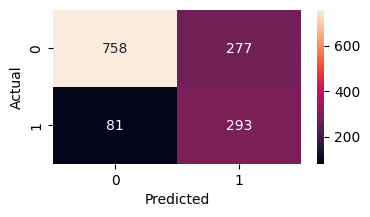

In [82]:
# Revised Decision Tree
revised_DT = DecisionTreeClassifier(criterion="entropy", random_state=42, max_depth=5, 
                                    class_weight="balanced", min_samples_leaf= 1,min_samples_split= 2,min_impurity_decrease=0.01)      
revised_DT.fit(X_train,y_train)
y_pred = revised_DT.predict(X_test)
y_train_pred = revised_DT.predict(X_train)

print("Train Precision:", precision_score(y_train, y_train_pred))
print("Test Precision:", precision_score(y_test, y_pred))
print("Train Recall:", recall_score(y_train, y_train_pred))
print("Test Recall:", recall_score(y_test, y_pred))
print("Train F1:", f1_score(y_train, y_train_pred))
print("Test F1:", f1_score(y_test, y_pred))
print(confusion_matrix(y_test,y_pred))

plt.figure(figsize=(4,2))
sns.heatmap(confusion_matrix(y_test,y_pred),annot=True,fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")

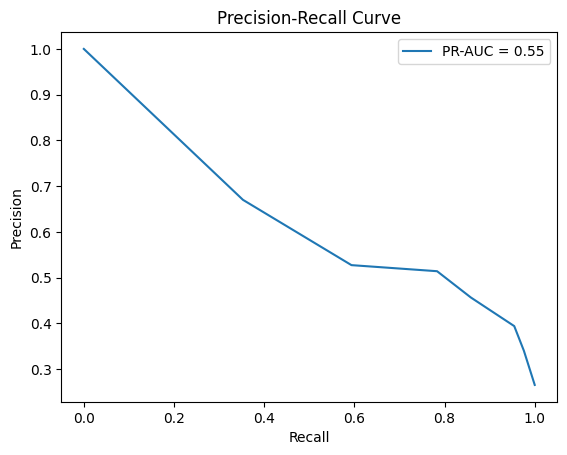

In [83]:
y_proba = revised_DT.predict_proba(X_test)[:,1]

precision, recall, thresholds = precision_recall_curve(y_test, y_proba)
pr_auc = average_precision_score(y_test, y_proba)

plt.plot(recall, precision, label=f"PR-AUC = {pr_auc:.2f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()

Train Precision: 0.6779156327543424
Test Precision: 0.5528942115768463
Train Recall: 0.9137123745819398
Test Recall: 0.7406417112299465
Train F1: 0.7783475783475784
Test F1: 0.6331428571428571
[[811 224]
 [ 97 277]]


Text(20.72222222222222, 0.5, 'Actual')

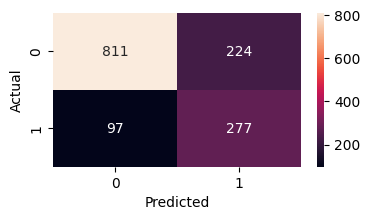

In [84]:
# 6.) Random Forest

model_rf = RandomForestClassifier(random_state=42,criterion='gini',n_estimators=100,max_depth=10,class_weight="balanced")      
model_rf.fit(X_train,y_train)
y_pred=model_rf.predict(X_test)
y_train_pred = model_rf.predict(X_train)

print("Train Precision:", precision_score(y_train, y_train_pred))
print("Test Precision:", precision_score(y_test, y_pred))
print("Train Recall:", recall_score(y_train, y_train_pred))
print("Test Recall:", recall_score(y_test, y_pred))
print("Train F1:", f1_score(y_train, y_train_pred))
print("Test F1:", f1_score(y_test, y_pred))
print(confusion_matrix(y_test,y_pred))

plt.figure(figsize=(4,2))
sns.heatmap(confusion_matrix(y_test,y_pred),annot=True,fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")

In [85]:
# Tuning
rf = RandomForestClassifier(random_state=42, class_weight="balanced")

rf_param_grid = {
    "n_estimators": [100,200],
    "max_depth": [3,5,10],
    "criterion": ["gini", "entropy"],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "min_impurity_decrease":[0.01,0.1,0.2]
}

rf_grid = RandomizedSearchCV(
    rf,
    rf_param_grid,
    cv=5,
    n_iter=100,
    scoring="f1",
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

print("Best params (Random Forest):", rf_grid.best_params_)
print("Best CV f1:", rf_grid.best_score_)

Best params (Random Forest): {'n_estimators': 100, 'min_samples_split': 10, 'min_samples_leaf': 4, 'min_impurity_decrease': 0.01, 'max_depth': 10, 'criterion': 'entropy'}
Best CV f1: 0.6242176123012115


Train Precision: 0.5188431200701139
Test Precision: 0.5103806228373703
Train Recall: 0.7919732441471572
Test Recall: 0.7887700534759359
Train F1: 0.6269526078898596
Test F1: 0.6197478991596639
[[752 283]
 [ 79 295]]


Text(20.72222222222222, 0.5, 'Actual')

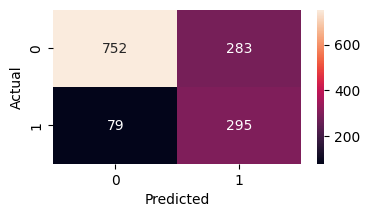

In [86]:
# Revised Random forest

revised_rf = RandomForestClassifier(n_estimators=100,criterion="entropy", random_state=42, max_depth=10, max_features='sqrt',
                                    class_weight="balanced", min_samples_leaf= 4,min_samples_split= 10,min_impurity_decrease=0.01)      
revised_rf.fit(X_train,y_train)
y_pred = revised_rf.predict(X_test)
y_train_pred = revised_rf.predict(X_train)

print("Train Precision:", precision_score(y_train, y_train_pred))
print("Test Precision:", precision_score(y_test, y_pred))
print("Train Recall:", recall_score(y_train, y_train_pred))
print("Test Recall:", recall_score(y_test, y_pred))
print("Train F1:", f1_score(y_train, y_train_pred))
print("Test F1:", f1_score(y_test, y_pred))
print(confusion_matrix(y_test,y_pred))

plt.figure(figsize=(4,2))
sns.heatmap(confusion_matrix(y_test,y_pred),annot=True,fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")

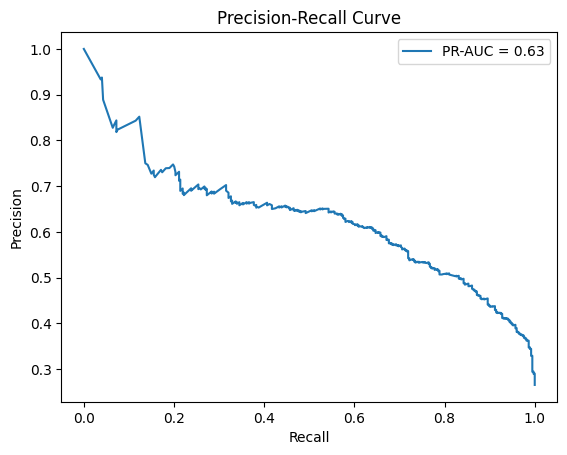

In [87]:
y_proba = revised_rf.predict_proba(X_test)[:,1]

precision, recall, thresholds = precision_recall_curve(y_test, y_proba)
pr_auc = average_precision_score(y_test, y_proba)

plt.plot(recall, precision, label=f"PR-AUC = {pr_auc:.2f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()

In [88]:
f1_scores = 2 * precision * recall / (precision + recall + 1e-10)

# best threshold index
best_idx = np.argmax(f1_scores)

# optimal threshold
best_threshold = thresholds[best_idx]
print("Best Threshold:", best_threshold)

Best Threshold: 0.5770542474735374


Test Precision: 0.5704989154013015
Test Recall: 0.7032085561497327
Test F1: 0.629940119760479
[[752 283]
 [ 79 295]]


Text(20.72222222222222, 0.5, 'Actual')

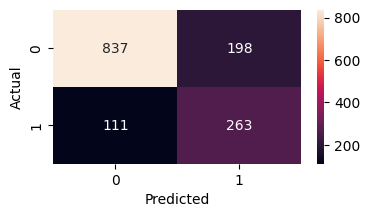

In [89]:
y1_pred = (y_proba >= 0.5770542474735374).astype(int)

print("Test Precision:", precision_score(y_test, y1_pred))
print("Test Recall:", recall_score(y_test, y1_pred))
print("Test F1:", f1_score(y_test, y1_pred))
print(confusion_matrix(y_test,y_pred))

plt.figure(figsize=(4,2))
sns.heatmap(confusion_matrix(y_test,y1_pred),annot=True,fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")

Train Precision: 0.835195530726257
Test Precision: 0.5545657015590201
Train Recall: 1.0
Test Recall: 0.6657754010695187
Train F1: 0.9101978691019786
Test F1: 0.6051032806804374
[[835 200]
 [125 249]]


Text(20.72222222222222, 0.5, 'Actual')

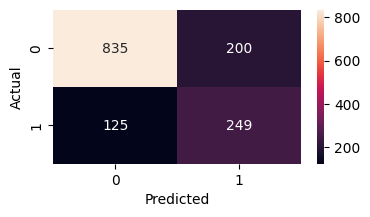

In [90]:
# 7.) xgb boost

xgb_clf = xgb.XGBClassifier(n_estimators=100,max_depth=10,learning_rate=0.1,eval_metric="logloss",random_state=42,scale_pos_weight=len(y_train[y_train==0]) / len(y_train[y_train==1]))
xgb_clf.fit(X_train,y_train)
y_pred=xgb_clf.predict(X_test)
y_train_pred = xgb_clf.predict(X_train)

print("Train Precision:", precision_score(y_train, y_train_pred))
print("Test Precision:", precision_score(y_test, y_pred))
print("Train Recall:", recall_score(y_train, y_train_pred))
print("Test Recall:", recall_score(y_test, y_pred))
print("Train F1:", f1_score(y_train, y_train_pred))
print("Test F1:", f1_score(y_test, y_pred))
print(confusion_matrix(y_test,y_pred))

plt.figure(figsize=(4,2))
sns.heatmap(confusion_matrix(y_test,y_pred),annot=True,fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")

In [91]:
# Tuning 

xgb_clf = xgb.XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    use_label_encoder=False,
    random_state=42
)

xgb_param_grid = {
    'max_depth': [3, 5, 7],
    'min_child_weight': [1, 3, 5],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [100, 300, 500],
    'gamma': [0.1, 0.3],
    'subsample': [0.7, 0.9, 1],
    'colsample_bytree': [0.7, 0.9, 1],
    'scale_pos_weight': [1, 3, 5, 10]
}

xgb_grid = RandomizedSearchCV(
    xgb_clf,
    xgb_param_grid,
    n_iter=100,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

xgb_grid.fit(X_train, y_train)

print("Best params (XGBoost):", xgb_grid.best_params_)
print("Best CV f1:", xgb_grid.best_score_)

Best params (XGBoost): {'subsample': 1, 'scale_pos_weight': 3, 'n_estimators': 500, 'min_child_weight': 1, 'max_depth': 3, 'learning_rate': 0.01, 'gamma': 0.1, 'colsample_bytree': 0.9}
Best CV f1: 0.6348192456885016


Train Precision: 0.5194274028629857
Test Precision: 0.5008103727714749
Train Recall: 0.8494983277591973
Test Recall: 0.8262032085561497
Train F1: 0.6446700507614214
Test F1: 0.6236125126135217
[[727 308]
 [ 65 309]]


Text(20.72222222222222, 0.5, 'Actual')

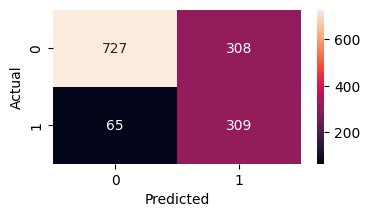

In [92]:
# Revised Xgb

revised_xgb = xgb.XGBClassifier(n_estimators=500, random_state=42, max_depth=3, learning_rate=0.01,gamma=0.1,subsample=1,
                                colsample_bytree=0.9, min_child_weight= 1,scale_pos_weight= 3)      
revised_xgb.fit(X_train,y_train)
y_pred = revised_xgb.predict(X_test)
y_train_pred = revised_xgb.predict(X_train)

print("Train Precision:", precision_score(y_train, y_train_pred))
print("Test Precision:", precision_score(y_test, y_pred))
print("Train Recall:", recall_score(y_train, y_train_pred))
print("Test Recall:", recall_score(y_test, y_pred))
print("Train F1:", f1_score(y_train, y_train_pred))
print("Test F1:", f1_score(y_test, y_pred))
print(confusion_matrix(y_test,y_pred))

plt.figure(figsize=(4,2))
sns.heatmap(confusion_matrix(y_test,y_pred),annot=True,fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")

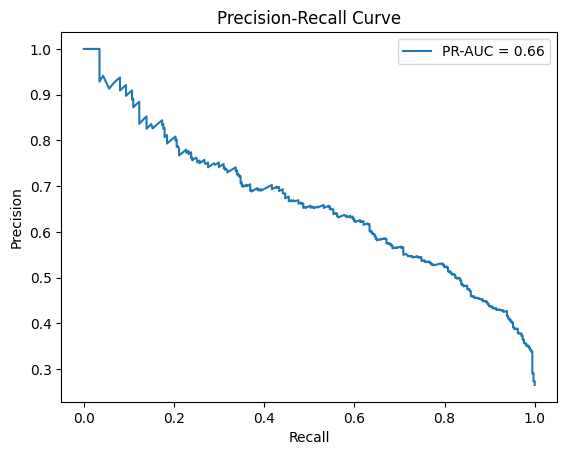

In [93]:
y_proba = revised_xgb.predict_proba(X_test)[:,1]

precision, recall, thresholds = precision_recall_curve(y_test, y_proba)
pr_auc = average_precision_score(y_test, y_proba)

plt.plot(recall, precision, label=f"PR-AUC = {pr_auc:.2f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()

In [94]:
f1_scores = 2 * precision * recall / (precision + recall + 1e-10)

# best threshold index
best_idx = np.argmax(f1_scores)

# optimal threshold
best_threshold = thresholds[best_idx]
print("Best Threshold:", best_threshold)

Best Threshold: 0.55040574


Test Precision: 0.5302491103202847
Test Recall: 0.7967914438502673
Test F1: 0.6367521367521367
[[727 308]
 [ 65 309]]


Text(20.72222222222222, 0.5, 'Actual')

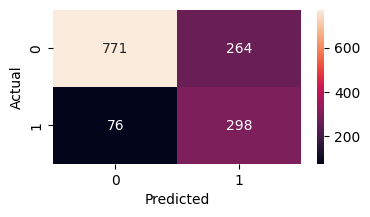

In [95]:
y1_pred = (y_proba >= 0.55040574).astype(int)

print("Test Precision:", precision_score(y_test, y1_pred))
print("Test Recall:", recall_score(y_test, y1_pred))
print("Test F1:", f1_score(y_test, y1_pred))
print(confusion_matrix(y_test,y_pred))

plt.figure(figsize=(4,2))
sns.heatmap(confusion_matrix(y_test,y1_pred),annot=True,fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")

ROC-AUC Score: 0.8445594047895838


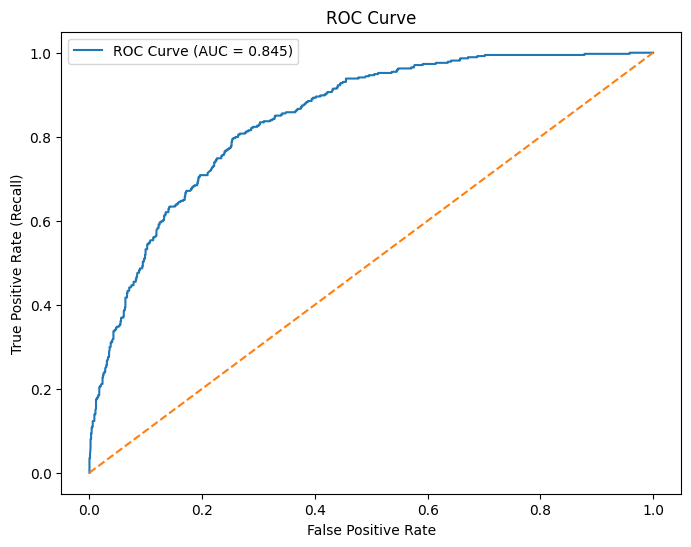

In [100]:
from sklearn.metrics import roc_curve, roc_auc_score

roc_auc = roc_auc_score(y_test, y_proba)

print("ROC-AUC Score:", roc_auc)
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
plt.figure(figsize=(8,6))

plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.3f})')

# Diagonal random classifier line
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve")
plt.legend()

plt.show()

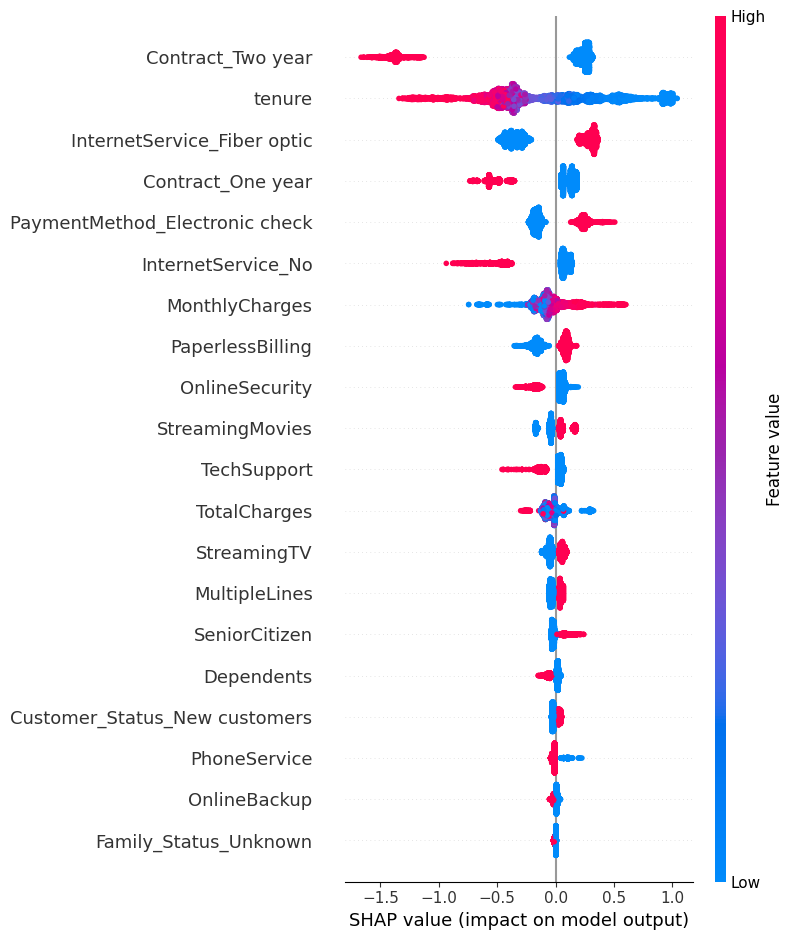

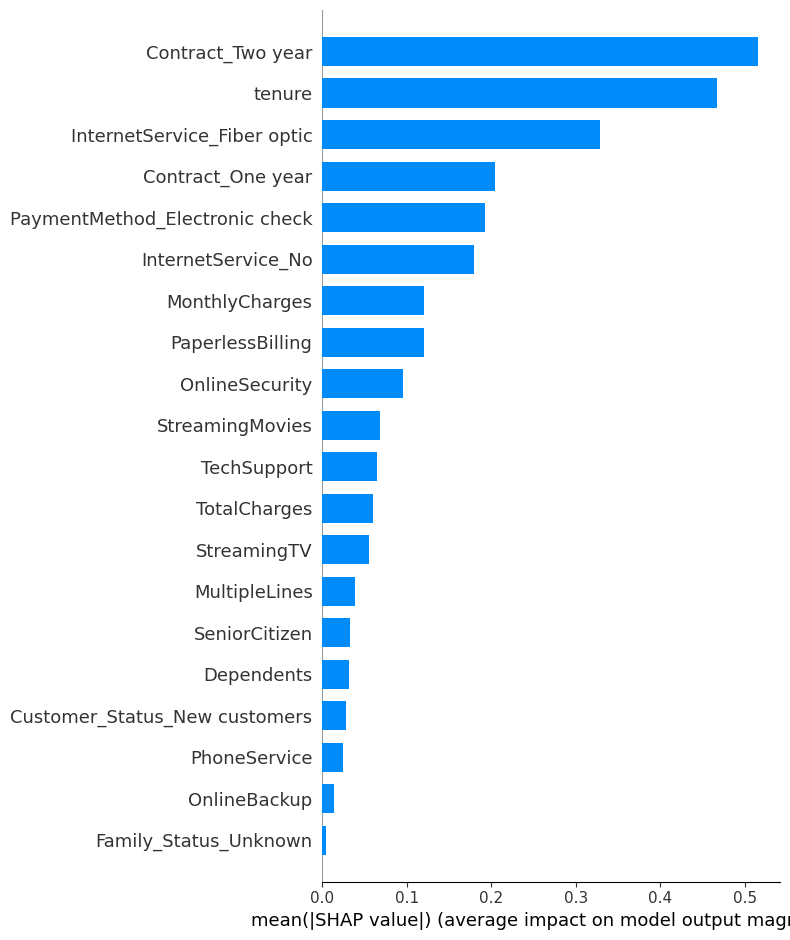

In [96]:
import shap

# Create SHAP explainer for your trained XGBoost model
explainer = shap.TreeExplainer(revised_xgb)

# Compute SHAP values for training data
shap_values = explainer.shap_values(X_train)

# Summary plot (global importance)
shap.summary_plot(shap_values, X_train)

# Bar plot (average absolute SHAP values)
shap.summary_plot(shap_values, X_train, plot_type="bar")